# 08a — First Steps: Topology, Functions as Vectors, and What Breaks in Infinite Dimensions

> *The gentle prequel to notebook 08. Start here if that one moves too fast.*

Notebook 08 opens at metric spaces and assumes you are comfortable with norms. This one
starts further back and goes slower, around four questions:

1. **What is a topology, and why does anyone care?** (§1)
2. **In what sense is a function a vector?** (§2)
3. **What does "infinite-dimensional" actually mean?** (§3)
4. **What specifically breaks there that never breaks in $\mathbb{R}^n$?** (§4–8)

Everything is a worked example with numbers. No proofs.

## The thing to hold on to

In $\mathbb{R}^n$ you get a long list of conveniences **for free**, and you have never had to
notice them because you have never been anywhere else. In infinite dimensions each one can
fail, and each failure has a name:

| Convenience | In $\mathbb{R}^n$ | Infinite dim | §  |
|---|---|---|---|
| Cauchy sequences converge | free | can fail $\Rightarrow$ **Banach** | 4 |
| all norms give the same limits | free | **false** | 5 |
| closed + bounded $\Rightarrow$ compact | free | **false** | 6 |
| linear maps are continuous | free | **false** | 7 |
| the norm has angles in it | *depends on the norm* | *depends* $\Rightarrow$ **Hilbert** | 8 |

The names (Banach, Hilbert) are just labels for "I am assuming that particular convenience
still holds here".

---
## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fractions import Fraction
from scipy.integrate import quad
from scipy.optimize import linprog

plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'font.size': 11, 'figure.dpi': 100})
sns.set_style("whitegrid")
np.set_printoptions(precision=5, suppress=True)
trapz = getattr(np, "trapezoid", None) or np.trapz

# Some macOS BLAS builds raise spurious FP warnings from matmul on exact data.
# The results are correct; this just keeps the output readable.
np.seterr(divide="ignore", over="ignore", invalid="ignore")
print(f"numpy {np.__version__}")

numpy 2.2.6


---
## 1. Topology vs topological space

Two words, one idea:

- a **topology** $\tau$ on a set $X$ is a choice of which subsets count as **open**;
- a **topological space** is the pair $(X, \tau)$ — the set *together with* that choice.

Same set, different choice of open sets, different space.

### 1.1 Why "open sets" at all?

Because they are the least you need to say what **continuous** means.

School definition: *"$f$ is continuous if points that are close map to points that are close."*
That needs a notion of distance. Topology replaces it with:

$$f \text{ is continuous} \iff \text{the preimage of every open set is open}$$

No distance required. Just a list of which sets are open.

### 1.2 The point: open sets are how you *separate* points

Take $X = \mathbb{R}$ and compare two topologies.

| | open sets | can you find an open set containing 0 but not 5? |
|---|---|---|
| **trivial** $\tau = \{\emptyset, \mathbb{R}\}$ | only two | **no** — the only set containing 0 is all of $\mathbb{R}$ |
| **standard** (all open intervals + unions) | many | **yes** — e.g. $(-1,1)$ |

"Separated" does not mean "both exist". It means **you can trap one in an open set that misses
the other**. Under the trivial topology every open set containing 0 also contains 5, so you
cannot.

In [2]:
# A topology as an explicit list of open sets, on a small set so we can check the axioms.
from itertools import combinations

X = frozenset({0, 5, 9})

def is_topology(tau, X):
    tau = set(map(frozenset, tau))
    if frozenset() not in tau or X not in tau:
        return False, "must contain the empty set and X"
    for A, B in combinations(tau, 2):
        if A | B not in tau:
            return False, f"union {set(A)} u {set(B)} missing"
        if A & B not in tau:
            return False, f"intersection {set(A)} n {set(B)} missing"
    return True, "valid topology"

candidates = {
    "trivial  {{}, X}":              [set(), set(X)],
    "discrete (every subset)":       [set(s) for r in range(4) for s in combinations(X, r)],
    "partial  {{}, {0}, X}":         [set(), {0}, set(X)],
    "BROKEN   {{}, {0}, {5}, X}":    [set(), {0}, {5}, set(X)],
}
print(f"X = {set(X)}\n")
for name, tau in candidates.items():
    ok, why = is_topology(tau, X)
    print(f"   {name:<28} {'OK ' if ok else 'NO '} {why}")
print("\nthe last one fails: {0} u {5} = {0,5} is not in the list, but unions of")
print("open sets must be open. The axioms are closure rules, nothing deeper.")

X = {0, 9, 5}

   trivial  {{}, X}             OK  valid topology
   discrete (every subset)      OK  valid topology
   partial  {{}, {0}, X}        OK  valid topology
   BROKEN   {{}, {0}, {5}, X}   NO  union {0} u {5} missing

the last one fails: {0} u {5} = {0,5} is not in the list, but unions of
open sets must be open. The axioms are closure rules, nothing deeper.


In [3]:
# Separation on the real line, made concrete.
def separates(topology, p, q):
    # can we find disjoint open sets, one containing p, the other q?
    if topology == "trivial":
        return False, "the only open set containing either point is all of R"
    if topology == "standard":
        r = abs(p - q) / 3
        return True, f"({p-r:.3g}, {p+r:.3g}) and ({q-r:.3g}, {q+r:.3g}) are disjoint"

for t in ["trivial", "standard"]:
    ok, why = separates(t, 0, 5)
    print(f"{t:>10} topology: separate 0 from 5?  {'YES' if ok else 'NO '}  -- {why}")

print("\nconsequence for limits. Take the sequence x_n = 1/n.")
n = np.arange(1, 9)
print(f"   x_n = {np.round(1/n, 5)}")
print("\n   standard topology: any interval around 0 eventually contains the whole tail,")
print("                      and NO interval around 5 ever does.   -> 1/n -> 0, uniquely")
print("   trivial topology : the only open set around ANY point is R, which contains the")
print("                      whole tail trivially.                 -> 1/n -> 0 AND 5 AND -37")
print("\nA topology too coarse to separate points is too coarse to have unique limits.")

   trivial topology: separate 0 from 5?  NO   -- the only open set containing either point is all of R
  standard topology: separate 0 from 5?  YES  -- (-1.67, 1.67) and (3.33, 6.67) are disjoint

consequence for limits. Take the sequence x_n = 1/n.
   x_n = [1.      0.5     0.33333 0.25    0.2     0.16667 0.14286 0.125  ]

   standard topology: any interval around 0 eventually contains the whole tail,
                      and NO interval around 5 ever does.   -> 1/n -> 0, uniquely
   trivial topology : the only open set around ANY point is R, which contains the
                      whole tail trivially.                 -> 1/n -> 0 AND 5 AND -37

A topology too coarse to separate points is too coarse to have unique limits.


### 1.3 A correction worth making

A common slip: *"under the trivial topology every function $f:\mathbb{R}\to\mathbb{R}$ is
continuous."*

**Continuity depends on the topology at *both* ends.** Spelling it out:

| domain | codomain | which $f$ are continuous? |
|---|---|---|
| trivial | trivial | **all** of them |
| standard | trivial | **all** of them |
| **trivial** | **standard** | only the **constant** ones |
| standard | standard | the usual ones |

Row 3 is the one people get wrong. If the domain is trivial, the only available preimages are
$\emptyset$ and $\mathbb{R}$. So for $f^{-1}\big((a,b)\big)$ to be open for *every* interval,
$f$ must send everything to a single point.

In [4]:
def continuous_trivial_to_standard(f, xs):
    # preimage of an open interval must be {} or all of R -> f must be constant
    vals = np.array([f(x) for x in xs])
    return np.allclose(vals, vals[0])

xs = np.linspace(-3, 3, 401)
tests = [("f(x) = 7            (constant)", lambda x: 7.0),
         ("f(x) = x            (identity)", lambda x: x),
         ("f(x) = x**2                    ", lambda x: x**2),
         ("f(x) = 0 if x<0 else 1  (step)", lambda x: 0.0 if x < 0 else 1.0)]

print("domain = trivial topology, codomain = standard topology\n")
print(f"{'function':<34}{'continuous?':>13}")
print("-" * 48)
for name, f in tests:
    print(f"{name:<34}{str(continuous_trivial_to_standard(f, xs)):>13}")
print("\nOnly the constant survives. In the OTHER direction (standard -> trivial)")
print("all four are continuous, because every preimage is {} or R automatically.")
print("Same functions, same sets, opposite answers. The topology on each side matters.")

domain = trivial topology, codomain = standard topology

function                            continuous?
------------------------------------------------
f(x) = 7            (constant)             True
f(x) = x            (identity)            False
f(x) = x**2                               False
f(x) = 0 if x<0 else 1  (step)            False

Only the constant survives. In the OTHER direction (standard -> trivial)
all four are continuous, because every preimage is {} or R automatically.
Same functions, same sets, opposite answers. The topology on each side matters.


---
## 2. A function *is* a vector

This sounds like a slogan. It is literally a re-reading of what a vector is.

A vector in $\mathbb{R}^3$, $v = (3, -1, 2)$, is a **rule assigning a number to each index**:

$$1 \mapsto 3, \qquad 2 \mapsto -1, \qquad 3 \mapsto 2$$

That is a function from $\{1,2,3\}$ to $\mathbb{R}$. You just never call it one, because the
index set is tiny.

Now let the index set be $[0,1]$ instead of $\{1,2,3\}$. The "vector" assigns a number to each
$x \in [0,1]$ — that is exactly a function $f(x)$.

| | finite vector | function |
|---|---|---|
| index runs over | $\{1,\dots,n\}$ | $[0,1]$ |
| component | $v_i$ | $f(x)$ |
| add | $(v+w)_i = v_i + w_i$ | $(f+g)(x) = f(x)+g(x)$ |
| scale | $(\alpha v)_i = \alpha v_i$ | $(\alpha f)(x) = \alpha f(x)$ |
| **sum over index** | $\sum_i$ | $\int dx$ |
| **dot product** | $\sum_i v_i w_i$ | $\int f(x)g(x)\,dx$ |

The last row is the whole idea. **The integral is the dot product**; the sum has become an
integral because the index became continuous.

In [5]:
# The same two operations, once on a vector and once on a function -- and the function
# version is literally the limit of the vector version as the grid gets finer.
v = np.array([3.0, -1.0, 2.0])
w = np.array([1.0,  4.0, 0.5])
print("finite:")
print(f"   v . w      = {v @ w}")
print(f"   ||v||      = {np.sqrt(v @ v):.6f}")

f = lambda x: x**2
g = lambda x: np.sin(np.pi * x)
ip_exact = quad(lambda x: f(x)*g(x), 0, 1)[0]
print(f"\nfunctions f(x)=x^2, g(x)=sin(pi x) on [0,1]:")
print(f"   <f,g> = int f g = {ip_exact:.8f}")
print(f"   ||f|| = sqrt(int f^2) = {np.sqrt(quad(lambda x: f(x)**2, 0, 1)[0]):.8f}")

print("\nsample the functions on n points and take an ordinary dot product,")
print("scaled by the grid spacing. Watch it converge to the integral:\n")
print(f"{'n':>8}{'(1/n) * sum f_i g_i':>24}{'error vs integral':>20}")
print("-" * 54)
for n in [4, 16, 64, 256, 1024, 4096]:
    xs = (np.arange(n) + 0.5) / n
    approx = (f(xs) @ g(xs)) / n
    print(f"{n:>8}{approx:>24.10f}{abs(approx - ip_exact):>20.2e}")
print("\nThe integral IS the dot product. Nothing new was introduced.")

finite:
   v . w      = 0.0
   ||v||      = 3.741657

functions f(x)=x^2, g(x)=sin(pi x) on [0,1]:
   <f,g> = int f g = 0.18930375
   ||f|| = sqrt(int f^2) = 0.44721360

sample the functions on n points and take an ordinary dot product,
scaled by the grid spacing. Watch it converge to the integral:

       n     (1/n) * sum f_i g_i   error vs integral
------------------------------------------------------
       4            0.1974456083            8.14e-03
      16            0.1898149495            5.11e-04
      64            0.1893357059            3.20e-05
     256            0.1893057458            2.00e-06
    1024            0.1893038733            1.25e-07
    4096            0.1893037563            7.80e-09

The integral IS the dot product. Nothing new was introduced.


### 2.1 Watch the vector turn into the function

A function sampled at $n$ points **is** a vector in $\mathbb{R}^n$ — you can draw its
components as bars. Increase $n$ and the bar chart becomes the graph. Nothing changes
qualitatively along the way; the only thing that grows is the number of components.

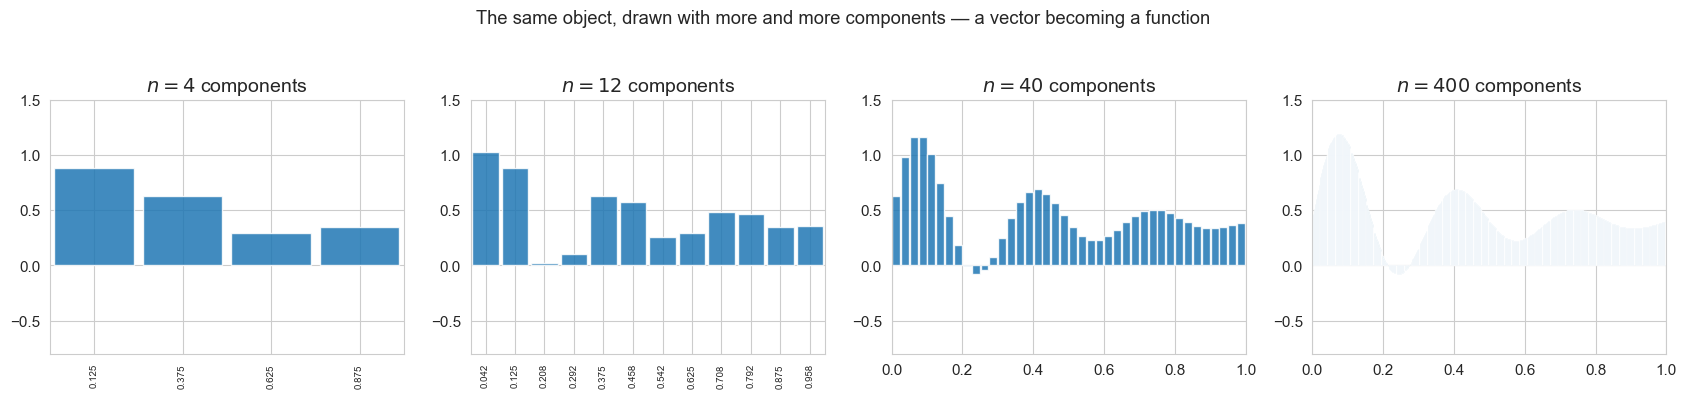

n = 4 :  a vector in R^4 you could write down by hand
   n=4  : [0.886  0.6296 0.2916 0.3488]
   n=12 : [1.024  0.886  0.0215 0.1052 0.6296 0.5788 0.2608 0.2916 0.4845 0.4658
 0.3488 0.3601]
n = 400: still just a vector, with 400 components
n -> infinity : the 'list of components' is the function h(x) itself


In [6]:
h = lambda x: np.exp(-3*x) * np.sin(6*np.pi*x) + 0.4

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, n in zip(axes, [4, 12, 40, 400]):
    xs_n = (np.arange(n) + 0.5) / n
    ax.bar(xs_n, h(xs_n), width=1.0/n * 0.9, color='C0', alpha=.85)
    ax.set_title(f"$n = {n}$ components")
    ax.set_ylim(-0.8, 1.5); ax.set_xlim(0, 1)
    if n <= 12:
        ax.set_xticks(np.round(xs_n, 3)); ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.suptitle("The same object, drawn with more and more components — "
             "a vector becoming a function", y=1.04)
plt.tight_layout(); plt.show()

print("n = 4 :  a vector in R^4 you could write down by hand")
for n in [4, 12]:
    xs_n = (np.arange(n) + 0.5) / n
    print(f"   n={n:<3}: {np.round(h(xs_n), 4)}")
print("n = 400: still just a vector, with 400 components")
print("n -> infinity : the 'list of components' is the function h(x) itself")

In [7]:
# And orthogonality is the SAME check in both worlds: is the dot product zero?
print("=== R^3: are these perpendicular? ===")
for a, b in [(np.array([1,0,0]), np.array([0,1,0])),
             (np.array([1,1,0]), np.array([1,-1,0])),
             (np.array([1,2,3]), np.array([4,5,6]))]:
    print(f"   {a} . {b} = {a@b:>6}   {'perpendicular' if a@b == 0 else 'not perpendicular'}")

print("\n=== functions on [0,1]: same question, sum replaced by integral ===")
pairs = [("sin(pi x)",  "sin(2 pi x)", lambda t: np.sin(np.pi*t),   lambda t: np.sin(2*np.pi*t)),
         ("sin(2 pi x)","cos(2 pi x)", lambda t: np.sin(2*np.pi*t), lambda t: np.cos(2*np.pi*t)),
         ("x",          "1",           lambda t: t,                 lambda t: 1.0 + 0*t)]
for n1, n2, u, v in pairs:
    ip = quad(lambda t: u(t)*v(t), 0, 1)[0]
    print(f"   <{n1:>11}, {n2:>11}> = {ip:>9.6f}   "
          f"{'ORTHOGONAL' if abs(ip) < 1e-9 else 'not orthogonal'}")

print("\nSame word, same test, same meaning. 'Orthogonal functions' is not a metaphor --")
print("it is the literal dot product with a continuous index.")

=== R^3: are these perpendicular? ===
   [1 0 0] . [0 1 0] =      0   perpendicular
   [1 1 0] . [ 1 -1  0] =      0   perpendicular
   [1 2 3] . [4 5 6] =     32   not perpendicular

=== functions on [0,1]: same question, sum replaced by integral ===
   <  sin(pi x), sin(2 pi x)> =  0.000000   ORTHOGONAL
   <sin(2 pi x), cos(2 pi x)> = -0.000000   ORTHOGONAL
   <          x,           1> =  0.500000   not orthogonal

Same word, same test, same meaning. 'Orthogonal functions' is not a metaphor --
it is the literal dot product with a continuous index.


---
## 3. What "infinite-dimensional" means

Dimension = how many basis vectors you need.

$\mathbb{R}^3$ needs 3. The space of functions on $[0,1]$ needs **infinitely many**, and you
genuinely cannot get away with fewer: no finite list of functions spans the rest.

Concretely, $\{1, \sin 2\pi x, \cos 2\pi x, \sin 4\pi x, \dots\}$ is a basis of $L^2[0,1]$, and
a general $f$ is an **infinite** sum, not a finite one.

Below: try to represent a square wave with $n$ basis functions and watch the error refuse to
reach zero for any finite $n$.

best approximation of a square wave using the first n basis functions:

  n (basis size)      L2 error
--------------------------------
               1      0.999937
               2      0.435093
               4      0.435093
               8      0.315027
              16      0.224226
              64      0.111966
             256      0.055159
            1024      0.025912

Still nonzero at n=1024, and it stays nonzero for EVERY finite n.
That is what infinite-dimensional means: no finite basis is enough.


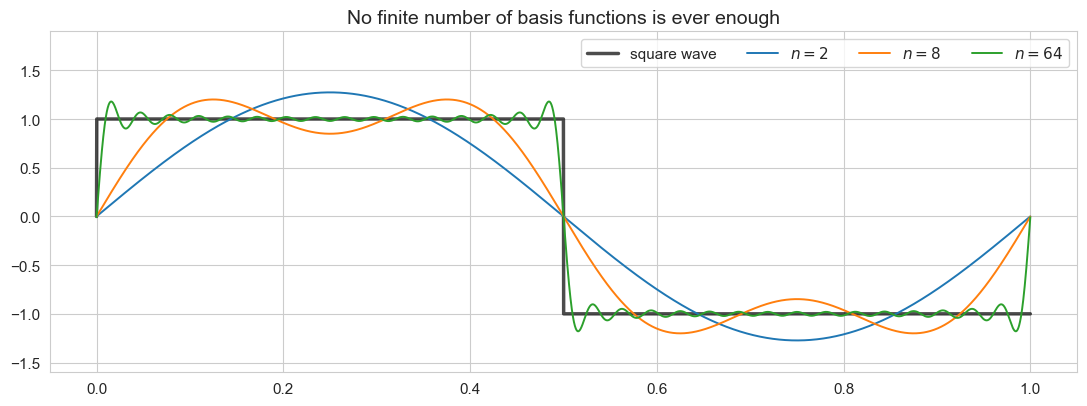

In [8]:
xs = np.linspace(0, 1, 4001)
target = np.sign(np.sin(2*np.pi*xs))          # square wave

def fourier_basis(k, xs):
    if k == 0:
        return np.ones_like(xs)
    m = (k + 1) // 2
    return np.sqrt(2) * (np.sin(2*np.pi*m*xs) if k % 2 == 1 else np.cos(2*np.pi*m*xs))

print("best approximation of a square wave using the first n basis functions:\n")
print(f"{'n (basis size)':>16}{'L2 error':>14}")
print("-" * 32)
for n in [1, 2, 4, 8, 16, 64, 256, 1024]:
    B = np.column_stack([fourier_basis(k, xs) for k in range(n)])
    coef = np.array([trapz(target * B[:, j], xs) for j in range(n)])
    approx = B @ coef
    print(f"{n:>16}{np.sqrt(trapz((approx-target)**2, xs)):>14.6f}")
print("\nStill nonzero at n=1024, and it stays nonzero for EVERY finite n.")
print("That is what infinite-dimensional means: no finite basis is enough.")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(xs, target, 'k', lw=2.5, alpha=.7, label='square wave')
for n, c in [(2, 'C0'), (8, 'C1'), (64, 'C2')]:
    B = np.column_stack([fourier_basis(k, xs) for k in range(n)])
    coef = np.array([trapz(target * B[:, j], xs) for j in range(n)])
    ax.plot(xs, B @ coef, c, lw=1.4, label=f'$n={n}$')
ax.legend(ncol=4); ax.set_ylim(-1.6, 1.9)
ax.set_title("No finite number of basis functions is ever enough")
plt.tight_layout(); plt.show()

---
## 4. Break 1 — Cauchy sequences can escape the space

**Cauchy** means the terms bunch up: $|x_n - x_m| \to 0$ as both grow. In $\mathbb{R}$ that
guarantees a limit. In a space with holes it does not — the sequence converges to something
*outside*.

### 4.1 The rationals

In [9]:
# Newton's method for sqrt(2), kept exactly rational.
x = Fraction(1)
rows = []
for n in range(6):
    rows.append((n, x, float(x)))
    x = (x + Fraction(2) / x) / 2

print("every term is a fraction, i.e. lives in Q:\n")
print(f"{'n':>3}{'x_n (exact)':>26}{'as a decimal':>16}{'gap to next':>15}")
print("-" * 62)
for i, (n, fr, fl) in enumerate(rows):
    gap = abs(float(rows[i+1][1]) - fl) if i+1 < len(rows) else float('nan')
    print(f"{n:>3}{f'{fr.numerator}/{fr.denominator}':>26}{fl:>16.12f}{gap:>15.2e}")

print(f"\ngaps -> 0, so the sequence is CAUCHY.")
print(f"its limit is sqrt(2) = {np.sqrt(2):.12f}, which is irrational.")
print("=> the limit is not in Q. Q is NOT complete.")

every term is a fraction, i.e. lives in Q:

  n               x_n (exact)    as a decimal    gap to next
--------------------------------------------------------------
  0                       1/1  1.000000000000       5.00e-01
  1                       3/2  1.500000000000       8.33e-02
  2                     17/12  1.416666666667       2.45e-03
  3                   577/408  1.414215686275       2.12e-06
  4             665857/470832  1.414213562375       1.59e-12
  5 886731088897/627013566048  1.414213562373            nan

gaps -> 0, so the sequence is CAUCHY.
its limit is sqrt(2) = 1.414213562373, which is irrational.
=> the limit is not in Q. Q is NOT complete.


### 4.2 "Then just add $\pi$?" — no

A natural thought: if $\mathbb{Q}$ is missing $\pi$, patch it — use $\mathbb{Q}\cup\{\pi\}$.
That does not work, because completeness is a statement about **every** Cauchy sequence, and
there are uncountably many other holes. Patching one leaves all the rest.

In [10]:
# Each of these sequences is entirely rational and Cauchy, and each escapes to a
# DIFFERENT irrational. Patching one hole does nothing for the others.
def rational_approx(target, n_digits):
    # truncate the decimal expansion: always a rational
    s = f"{target:.{n_digits}f}"
    return Fraction(int(s.replace('.', '')), 10**n_digits)

targets = {"sqrt(2)": np.sqrt(2), "pi": np.pi, "e": np.e,
           "sqrt(3)": np.sqrt(3), "golden ratio": (1+np.sqrt(5))/2}
print("all terms rational, all sequences Cauchy, all limits irrational:\n")
print(f"{'limit':>14}{'x_6 (rational)':>26}{'distance to limit':>20}")
print("-" * 62)
for name, t in targets.items():
    fr = rational_approx(t, 6)
    print(f"{name:>14}{f'{fr.numerator}/{fr.denominator}':>26}{abs(float(fr)-t):>20.2e}")

print("\nAdding pi to Q fixes the pi hole and nothing else: the sqrt(2) sequence still")
print("escapes. To fix them ALL you must add every limit of every Cauchy sequence --")
print("and doing exactly that is one of the standard constructions of R.")

all terms rational, all sequences Cauchy, all limits irrational:

         limit            x_6 (rational)   distance to limit
--------------------------------------------------------------
       sqrt(2)             707107/500000            4.38e-07
            pi           3141593/1000000            3.46e-07
             e            1359141/500000            1.72e-07
       sqrt(3)           1732051/1000000            1.92e-07
  golden ratio             809017/500000            1.13e-08

Adding pi to Q fixes the pi hole and nothing else: the sqrt(2) sequence still
escapes. To fix them ALL you must add every limit of every Cauchy sequence --
and doing exactly that is one of the standard constructions of R.


### 4.3 The same failure with functions

Take the **polynomials** on $[0,1]$, measured by $\|p\| = \max_{x}|p(x)|$. Taylor partial sums
of $e^x$ are polynomials, they bunch up, and their limit $e^x$ is **not a polynomial**.

In [11]:
xs = np.linspace(0, 1, 2001)
import math
def taylor(x, n):
    return sum(x**k / math.factorial(k) for k in range(n+1))

print("sup-norm distance between consecutive Taylor polynomials for e^x on [0,1]:\n")
print(f"{'n':>4}{'||p_n - p_(n+1)||_sup':>26}{'||p_n - e^x||_sup':>22}")
print("-" * 54)
for n in [1, 2, 4, 8, 12, 16]:
    a, b = taylor(xs, n), taylor(xs, n+1)
    print(f"{n:>4}{np.abs(a-b).max():>26.3e}{np.abs(a-np.exp(xs)).max():>22.3e}")

print("\nthe terms bunch up (column 2 -> 0): CAUCHY.")
print("they converge to e^x (column 3 -> 0).")
print("but e^x is not a polynomial -- a degree-d polynomial has zero (d+1)-th derivative,")
print("while every derivative of e^x is e^x, never zero.")
print("=> the space of polynomials with the sup norm is NOT complete.")
print("   Enlarging to C[0,1] (all continuous functions) fixes it: that one IS complete.")

sup-norm distance between consecutive Taylor polynomials for e^x on [0,1]:

   n     ||p_n - p_(n+1)||_sup     ||p_n - e^x||_sup
------------------------------------------------------
   1                 5.000e-01             7.183e-01
   2                 1.667e-01             2.183e-01
   4                 8.333e-03             9.948e-03
   8                 2.756e-06             3.059e-06
  12                 1.606e-10             1.729e-10
  16                 2.665e-15             3.553e-15

the terms bunch up (column 2 -> 0): CAUCHY.
they converge to e^x (column 3 -> 0).
but e^x is not a polynomial -- a degree-d polynomial has zero (d+1)-th derivative,
while every derivative of e^x is e^x, never zero.
=> the space of polynomials with the sup norm is NOT complete.
   Enlarging to C[0,1] (all continuous functions) fixes it: that one IS complete.


### 4.4 Why completeness is worth having: existence for free

The payoff is that you can prove a solution **exists** without constructing it.

**Contraction mapping theorem.** If $X$ is complete and $T:X\to X$ shrinks distances
($d(Tx,Ty)\le c\,d(x,y)$ with $c<1$), then $T$ has exactly one fixed point $Tx=x$, and
iterating from anywhere converges to it.

Completeness is doing all the work: the iterates are Cauchy, and you need them to have
somewhere to land.

In [12]:
# Picard iteration for  f(x) = 1 + int_0^x f  (whose solution is e^x), on [0, 1/2].
xs2 = np.linspace(0, 0.5, 801)
f_cur = np.zeros_like(xs2)
print("iterating  (Tf)(x) = 1 + int_0^x f(t) dt   starting from f = 0:\n")
print(f"{'step':>6}{'||T f - f||_sup':>20}{'||f - e^x||_sup':>20}")
print("-" * 48)
for k in range(9):
    f_new = 1 + np.concatenate([[0], np.cumsum((f_cur[1:] + f_cur[:-1])/2 * np.diff(xs2))])
    print(f"{k:>6}{np.abs(f_new - f_cur).max():>20.3e}{np.abs(f_new - np.exp(xs2)).max():>20.3e}")
    f_cur = f_new

print("\nthe steps shrink geometrically -> the sequence is Cauchy.")
print("In C[0,1/2] (complete) the limit e^x exists, so a solution is GUARANTEED.")
print("In the polynomials (not complete) the same iteration runs fine but the theorem")
print("does not apply -- the limit could have been in a hole.")

iterating  (Tf)(x) = 1 + int_0^x f(t) dt   starting from f = 0:

  step     ||T f - f||_sup     ||f - e^x||_sup
------------------------------------------------
     0           1.000e+00           6.487e-01
     1           5.000e-01           1.487e-01
     2           1.250e-01           2.372e-02
     3           2.083e-02           2.888e-03
     4           2.604e-03           2.837e-04
     5           2.604e-04           2.333e-05
     6           2.170e-05           1.626e-06
     7           1.550e-06           7.572e-08
     8           9.689e-08           2.134e-08

the steps shrink geometrically -> the sequence is Cauchy.
In C[0,1/2] (complete) the limit e^x exists, so a solution is GUARANTEED.
In the polynomials (not complete) the same iteration runs fine but the theorem
does not apply -- the limit could have been in a hole.


---
## 5. Break 2 — different norms stop agreeing

In $\mathbb{R}^n$ all norms are **equivalent**: each is bounded by a constant times another,
so they produce the same convergent sequences. Which norm you pick is a matter of taste.

In infinite dimensions that fails, and the classic witness is a **spike**: tall and thin, so
its height blows up while its area stays fixed.

$$f_n(x) = \begin{cases} n & 0 \le x \le 1/n \\ 0 & \text{otherwise}\end{cases}
\qquad \|f_n\|_\infty = n, \qquad \|f_n\|_1 = 1$$

       n     ||f_n||_sup     ||f_n||_1     ||f_n||_2
----------------------------------------------------
       1             1.0      1.000000        1.0000
       2             2.0      1.000005        1.4142
       8             8.0      1.000020        2.8285
      64            64.0      1.000160        8.0006
     512           512.0      0.999680       22.6238
    4096          4096.0      0.993280       63.7846

||f_n||_1 stays at 1 -- BOUNDED.
||f_n||_sup = n     -- UNBOUNDED.
So 'bounded' is not a property of the sequence; it is a property of the
sequence AND the norm. In R^n that distinction does not exist.


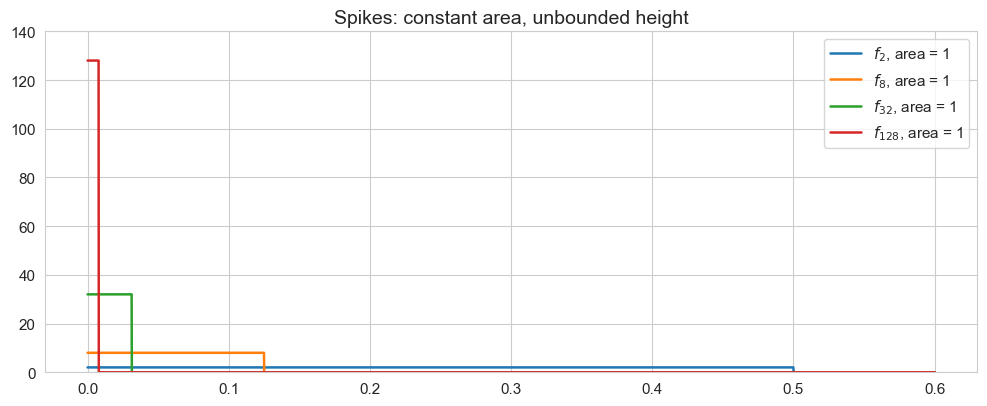

In [13]:
def spike(x, n):
    return np.where(x <= 1.0/n, float(n), 0.0)

xs3 = np.linspace(0, 1, 200001)
print(f"{'n':>8}{'||f_n||_sup':>16}{'||f_n||_1':>14}{'||f_n||_2':>14}")
print("-" * 52)
for n in [1, 2, 8, 64, 512, 4096]:
    f = spike(xs3, n)
    print(f"{n:>8}{f.max():>16.1f}{trapz(f, xs3):>14.6f}{np.sqrt(trapz(f**2, xs3)):>14.4f}")

print("\n||f_n||_1 stays at 1 -- BOUNDED.")
print("||f_n||_sup = n     -- UNBOUNDED.")
print("So 'bounded' is not a property of the sequence; it is a property of the")
print("sequence AND the norm. In R^n that distinction does not exist.")

fig, ax = plt.subplots(figsize=(10, 4.2))
for n, c in [(2,'C0'), (8,'C1'), (32,'C2'), (128,'C3')]:
    xx = np.linspace(0, 0.6, 4001)
    ax.plot(xx, spike(xx, n), c, lw=1.8, label=f'$f_{{{n}}}$, area = 1')
ax.set_ylim(0, 140); ax.legend()
ax.set_title("Spikes: constant area, unbounded height")
plt.tight_layout(); plt.show()

---
## 6. Break 3 — closed and bounded no longer means compact

In $\mathbb{R}^n$ (Heine–Borel), a closed bounded set is **compact**: every sequence in it has
a convergent subsequence. That is the standard reason a continuous function on such a set
attains its minimum.

In infinite dimensions the closed unit ball is **never** compact. The witness is an
orthonormal sequence: every term sits on the unit sphere, yet they are all the same fixed
distance $\sqrt2$ apart, so no subsequence can ever bunch up.

In [14]:
xs4 = np.linspace(0, 1, 100001)
def e_n(n, x):
    return np.sqrt(2) * np.sin(n * np.pi * x)

print("e_n(x) = sqrt(2) sin(n pi x) in L^2[0,1]\n")
print(f"{'n':>4}{'||e_n||':>12}")
print("-" * 18)
for n in [1, 2, 3, 7, 20]:
    print(f"{n:>4}{np.sqrt(trapz(e_n(n,xs4)**2, xs4)):>12.8f}")
print("   all on the unit sphere -> the set is BOUNDED\n")

print("pairwise distances:")
print(f"{'n':>4}{'m':>4}{'<e_n,e_m>':>14}{'||e_n - e_m||':>16}")
print("-" * 40)
for n, m in [(1,2), (1,3), (2,5), (3,7), (4,11)]:
    ip = trapz(e_n(n,xs4)*e_n(m,xs4), xs4)
    d = np.sqrt(trapz((e_n(n,xs4)-e_n(m,xs4))**2, xs4))
    print(f"{n:>4}{m:>4}{ip:>14.2e}{d:>16.8f}")
print(f"\n   every pair is exactly sqrt(2) = {np.sqrt(2):.8f} apart, forever.")
print("   No subsequence gets closer => NO convergent subsequence => NOT compact.")
print("\nWhy it matters: 'a continuous function on a closed bounded set attains its")
print("minimum' is FALSE here. Existence of minimisers has to be argued another way.")

e_n(x) = sqrt(2) sin(n pi x) in L^2[0,1]

   n     ||e_n||
------------------
   1  1.00000000
   2  1.00000000
   3  1.00000000
   7  1.00000000
  20  1.00000000
   all on the unit sphere -> the set is BOUNDED

pairwise distances:
   n   m     <e_n,e_m>   ||e_n - e_m||
----------------------------------------
   1   2     -5.65e-17      1.41421356
   1   3     -1.78e-17      1.41421356


   2   5      7.37e-18      1.41421356
   3   7      8.89e-18      1.41421356
   4  11      1.14e-16      1.41421356

   every pair is exactly sqrt(2) = 1.41421356 apart, forever.
   No subsequence gets closer => NO convergent subsequence => NOT compact.

Why it matters: 'a continuous function on a closed bounded set attains its
minimum' is FALSE here. Existence of minimisers has to be argued another way.


---
## 7. Break 4 — linear maps can be discontinuous

Every linear map $\mathbb{R}^n \to \mathbb{R}^m$ is continuous; it is a matrix, and matrices
cannot jump. In infinite dimensions linearity no longer implies continuity, and the standard
example is the one operation you use constantly: **differentiation**.

Take $p_n(x) = x^n$ on $[0,1]$. Then $\|p_n\|_\infty = 1$, but $p_n' = n x^{n-1}$ has
$\|p_n'\|_\infty = n$. Bounded in, unbounded out.

In [15]:
xs5 = np.linspace(0, 1, 20001)
print("D(p) = p'  on polynomials over [0,1], sup norm\n")
print(f"{'n':>6}{'||x^n||_sup':>16}{'||d/dx x^n||_sup':>20}{'ratio':>10}")
print("-" * 54)
for n in [1, 2, 5, 20, 100, 1000]:
    p = xs5**n
    dp = n * xs5**(n-1)
    print(f"{n:>6}{p.max():>16.4f}{dp.max():>20.1f}{dp.max()/p.max():>10.1f}")

print("\ninput norm is always 1; output norm is n and grows without bound.")
print("A continuous linear map must satisfy ||Dp|| <= C ||p|| for SOME fixed C.")
print("No such C exists here => differentiation is an UNBOUNDED operator.")
print("\nThis is not a pathology anyone avoids -- it is why quantum mechanics has to")
print("worry about operator domains: the Hamiltonian -d^2/dx^2 is unbounded too.")

D(p) = p'  on polynomials over [0,1], sup norm

     n     ||x^n||_sup    ||d/dx x^n||_sup     ratio
------------------------------------------------------
     1          1.0000                 1.0       1.0
     2          1.0000                 2.0       2.0
     5          1.0000                 5.0       5.0
    20          1.0000                20.0      20.0
   100          1.0000               100.0     100.0
  1000          1.0000              1000.0    1000.0

input norm is always 1; output norm is n and grows without bound.
A continuous linear map must satisfy ||Dp|| <= C ||p|| for SOME fixed C.
No such C exists here => differentiation is an UNBOUNDED operator.

This is not a pathology anyone avoids -- it is why quantum mechanics has to
worry about operator domains: the Hamiltonian -d^2/dx^2 is unbounded too.


---
## 8. Break 5 — a norm need not contain any angles

A norm gives **length**. It does not automatically give **angle**. Angle needs an inner
product, and only some norms come from one.

The test is the **parallelogram law**:

$$\|f+g\|^2 + \|f-g\|^2 \;\overset{?}{=}\; 2\|f\|^2 + 2\|g\|^2$$

A norm satisfies it **exactly when** it comes from an inner product. Same two functions,
two norms, two verdicts.

In [16]:
xs6 = np.linspace(0, 1, 200001)
f = xs6
g = 1 - xs6

def sup_norm(h):  return np.abs(h).max()
def l2_norm(h):   return np.sqrt(trapz(h**2, xs6))

print("f(x) = x,  g(x) = 1 - x  on [0,1]\n")
for name, nrm in [("sup norm  ||h|| = max|h|", sup_norm),
                  ("L2 norm   ||h|| = sqrt(int h^2)", l2_norm)]:
    lhs = nrm(f+g)**2 + nrm(f-g)**2
    rhs = 2*nrm(f)**2 + 2*nrm(g)**2
    ok = abs(lhs - rhs) < 1e-8
    print(f"{name}")
    print(f"   ||f|| = {nrm(f):.6f}   ||g|| = {nrm(g):.6f}")
    print(f"   ||f+g|| = {nrm(f+g):.6f}   ||f-g|| = {nrm(f-g):.6f}")
    print(f"   LHS = {lhs:.6f}   RHS = {rhs:.6f}   -> {'HOLDS' if ok else 'FAILS'}")
    print(f"   {'inner product exists -> angles, orthogonality, projection' if ok else 'no inner product -> no notion of angle at all'}\n")

print("Under the L2 norm we can even measure the angle between f and g:")
ip = trapz(f*g, xs6)
cos = ip / (l2_norm(f)*l2_norm(g))
print(f"   <f,g> = int x(1-x) dx = {ip:.6f}  (exactly 1/6 = {1/6:.6f})")
print(f"   cos(theta) = {cos:.6f}  ->  theta = {np.degrees(np.arccos(cos)):.3f} degrees")
print("\nUnder the sup norm that question has no answer. Not 'hard to compute' -- undefined.")

f(x) = x,  g(x) = 1 - x  on [0,1]

sup norm  ||h|| = max|h|
   ||f|| = 1.000000   ||g|| = 1.000000
   ||f+g|| = 1.000000   ||f-g|| = 1.000000
   LHS = 2.000000   RHS = 4.000000   -> FAILS
   no inner product -> no notion of angle at all

L2 norm   ||h|| = sqrt(int h^2)
   ||f|| = 0.577350   ||g|| = 0.577350
   ||f+g|| = 1.000000   ||f-g|| = 0.577350
   LHS = 1.333333   RHS = 1.333333   -> HOLDS
   inner product exists -> angles, orthogonality, projection

Under the L2 norm we can even measure the angle between f and g:
   <f,g> = int x(1-x) dx = 0.166667  (exactly 1/6 = 0.166667)
   cos(theta) = 0.500000  ->  theta = 60.000 degrees

Under the sup norm that question has no answer. Not 'hard to compute' -- undefined.


---
## 9. Two things worth getting right

### 9.1 Least squares does **not** require a Hilbert space

Ordinary regression lives in $\mathbb{R}^n$, which is finite-dimensional and therefore a
Hilbert space automatically. Nothing is being assumed and nothing could fail.

What Hilbert structure actually buys is the **infinite-dimensional** version: approximating a
*function* by a subspace of functions, with a guarantee that a unique best answer exists.

### 9.2 "Banach spaces cannot do best approximation" is too strong

A tempting story is: *Hilbert gives unique projections, so in a Banach space like $C[0,1]$
with the sup norm the best approximation might not exist or might not be unique.*

For polynomials that is **false**. The best uniform approximation by polynomials of degree
$\le n$ exists and is unique — Chebyshev, 1850s — and it is characterised by the error
**equioscillating** at $n+2$ points with alternating signs.

The accurate statement is sharper:

> In a **Hilbert** space, uniqueness of the nearest point is automatic for *every* closed
> subspace. In a **Banach** space you may still get it, but only when the geometry happens to
> cooperate — as it does for polynomials in the sup norm, and does **not** in general.

best degree-2 approximation to e^x on [0,1]

fitted by                  sup error      L2 error
--------------------------------------------------
minimax (sup norm)        0.00875602    0.00610211
projection (L2)           0.01496951    0.00527594
   each wins in its own norm, as it must.

equioscillation check on the minimax error:
         x          error   sign
   0.00000     0.00875602      1
   0.26575    -0.00875602     -1
   0.76525     0.00875602      1
   1.00000    -0.00875602     -1

   extrema        : 4   (Chebyshev requires deg+2 = 4)
   equal in size? : spread = 3.55e-15
   alternating?   : True

=> the minimax polynomial EXISTS and is UNIQUE, in a Banach space with no
   inner product anywhere. Hilbert makes uniqueness automatic; it is not the
   only way to get it.


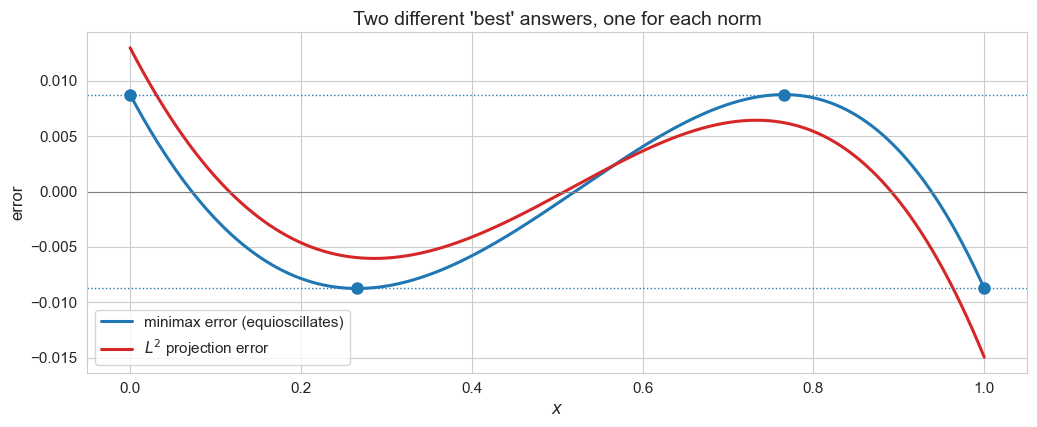

In [17]:
# Best degree-2 approximation to e^x on [0,1], in each of two norms.
xs7 = np.linspace(0, 1, 4001)
fx  = np.exp(xs7)
deg = 2
V = np.vander(xs7, deg+1, increasing=True)

# minimax fit via linear programming: min t  s.t.  -t <= Vc - f <= t
nrows = V.shape[0]; m = deg+1
A = np.vstack([np.hstack([ V, -np.ones((nrows,1))]),
               np.hstack([-V, -np.ones((nrows,1))])])
b = np.concatenate([fx, -fx])
res = linprog(np.r_[np.zeros(m), 1.0], A_ub=A, b_ub=b,
              bounds=[(None,None)]*m + [(0,None)], method="highs")
c_inf = res.x[:m]
c_l2, *_ = np.linalg.lstsq(V, fx, rcond=None)
e_inf, e_l2 = V @ c_inf - fx, V @ c_l2 - fx

print("best degree-2 approximation to e^x on [0,1]\n")
print(f"{'fitted by':<22}{'sup error':>14}{'L2 error':>14}")
print("-" * 50)
for nm, e in [("minimax (sup norm)", e_inf), ("projection (L2)", e_l2)]:
    print(f"{nm:<22}{np.abs(e).max():>14.8f}{np.sqrt(trapz(e**2, xs7)):>14.8f}")
print("   each wins in its own norm, as it must.\n")

# equioscillation = Chebyshev's uniqueness certificate
sgn = np.sign(e_inf)
cuts = np.r_[0, np.flatnonzero(np.diff(sgn) != 0), len(xs7)-1]
ext = []
for lo, hi in zip(cuts[:-1], cuts[1:]):
    seg = e_inf[lo:hi+1]
    ext.append(lo + (np.argmax(seg) if seg[len(seg)//2] > 0 else np.argmin(seg)))
ext = sorted(set(ext))
print("equioscillation check on the minimax error:")
print(f"{'x':>10}{'error':>15}{'sign':>7}")
for k in ext:
    print(f"{xs7[k]:>10.5f}{e_inf[k]:>15.8f}{int(np.sign(e_inf[k])):>7}")
print(f"\n   extrema        : {len(ext)}   (Chebyshev requires deg+2 = {deg+2})")
print(f"   equal in size? : spread = {np.ptp(np.abs(e_inf[ext])):.2e}")
print(f"   alternating?   : {all(np.sign(e_inf[ext][i])*np.sign(e_inf[ext][i+1])<0 for i in range(len(ext)-1))}")
print("\n=> the minimax polynomial EXISTS and is UNIQUE, in a Banach space with no")
print("   inner product anywhere. Hilbert makes uniqueness automatic; it is not the")
print("   only way to get it.")

fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.plot(xs7, e_inf, lw=2.2, color='C0', label='minimax error (equioscillates)')
ax.plot(xs7, e_l2, lw=2.2, color='C3', label='$L^2$ projection error')
for k in ext:
    ax.plot(xs7[k], e_inf[k], 'o', color='C0', ms=8)
ax.axhline(0, color='grey', lw=.8)
for s in (+1, -1):
    ax.axhline(s*np.abs(e_inf).max(), color='C0', ls=':', lw=1)
ax.legend(); ax.set_xlabel("$x$"); ax.set_ylabel("error")
ax.set_title("Two different 'best' answers, one for each norm")
plt.tight_layout(); plt.show()

---
## 10. Summary, and where to go next

| § | Question | Short answer |
|---|---|---|
| 1 | topology vs topological space | the topology is the choice of open sets; the space is set + choice |
| 1 | why open sets | they are the least you need to define continuity, with no distance |
| 1 | what "separate" means | trap one point in an open set that misses the other |
| 2 | how is a function a vector | same thing with a continuous index; $\sum \to \int$ |
| 3 | what infinite-dimensional means | no finite basis is ever enough |
| 4 | why completeness | Cauchy sequences can escape; completeness gives existence proofs |
| 5 | why the norm matters | different norms disagree about what is bounded |
| 6 | why compactness fails | orthonormal points stay $\sqrt2$ apart forever |
| 7 | why continuity of linear maps matters | differentiation is unbounded |
| 8 | why inner products | a norm gives length; only some norms give angle |

**The through-line.** None of this is bureaucracy. Each named structure is a promise that one
specific $\mathbb{R}^n$ convenience still holds:

$$\underbrace{\text{Banach}}_{\text{limits stay put}} \qquad
\underbrace{\text{Hilbert}}_{\text{angles still exist}}$$

**Next:** [notebook 08](08_metric_normed_banach_hilbert_spaces.ipynb) takes the same ladder
and pushes it — the parallelogram law across every $p$-norm, the projection theorem as
ordinary least squares, Gram–Schmidt producing the Legendre polynomials, Gibbs phenomenon,
and the kernel trick as an inner product in disguise.

Then [10](10_manifolds_charts_and_the_axioms.ipynb) for manifolds, and
[09](09_lie_groups_and_lie_algebras.ipynb) for Lie groups.